# Leakage-safe multi-label prediction of author contribution roles

This notebook predicts the **self-declared CRediT roles** of an author–article record from article and authorship metadata.

It directly addresses the methodological concerns raised by the reviewers:

1. The split is performed at the **article level**, not the author-row level.
2. The held-out test set is not used for preprocessing, hyperparameter selection, threshold selection, or model selection.
3. All preprocessing is fitted inside the cross-validation pipeline.
4. Class imbalance is handled explicitly.
5. Precision, recall, F1, average precision, and multi-label metrics are reported in addition to accuracy.
6. The target-derived variable `number_of_tasks` is excluded because it would leak information from the outcome.
7. Dummy, logistic-regression, and XGBoost models are evaluated under the same split.
8. Optional temporal and unseen-journal/domain tests are provided to assess external generalization.

**Interpretation:** the models predict reported contribution labels. They do not identify causal effects or verify the authors' actual labor.

## 1. Environment

The `iterative-stratification` package is used to preserve multi-label prevalence while keeping every article wholly within one partition.

In [ ]:
!pip -q install iterative-stratification xgboost

In [ ]:
import ast
import json
import math
import random
import re
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from iterstrat.ml_stratifiers import (
    MultilabelStratifiedKFold,
    MultilabelStratifiedShuffleSplit,
)

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    fbeta_score,
    hamming_loss,
    jaccard_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## 2. Configuration

Edit only this cell before running the notebook.

### Required data structure

Each row must represent one author in one article.

- Target: `contribution type`
- Categorical predictors: `field`, `domain`
- Numeric predictors: `number_of_authors`, `normalized_author_position`
- Article identifier: preferably DOI or a stable article ID. If neither exists, the notebook constructs a key from title, year, and journal.
- `number_of_tasks` is retained only for descriptive checks and is **never** used as a predictor.

In [ ]:
# ---------- Input ----------
DATA_PATH = "/content/all_author_tasks_df.csv"
TARGET_COLUMN = "contribution_type"

# Predictors used in the primary model
CATEGORICAL_FEATURES = ["field", "domain"]
NUMERIC_FEATURES = [
    "number_of_authors",
    "normalized_author_position",
]

# Candidate article identifiers, in order of preference
ARTICLE_ID_CANDIDATES = [
    "article_id",
    "doi",
    "DOI",
    "title",
]

# Optional columns for robustness analyses
TITLE_COLUMN = "title"
YEAR_COLUMN = "year"
JOURNAL_COLUMN = "journal"

# ---------- Experimental design ----------
TEST_SIZE = 0.20
N_CV_SPLITS = 5
THRESHOLD_BETA = 1.0     # 1.0 optimizes F1; 2.0 gives greater weight to recall
N_JOBS = -1
XGB_SEARCH_ITERATIONS = 8

# Empty targets normally indicate missing labels rather than true "no contribution".
DROP_EMPTY_TARGET_ROWS = True

# Fail rather than silently discard an unrecognized target label.
STRICT_TARGET_VALIDATION = True

# Output directory
OUTPUT_DIR = Path("/content/predictive_model_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3. Load the data without blanket row deletion

The original notebook used `dropna()`, which may remove many records and can change the role distribution. Here, missing predictors are handled inside the training pipeline. Only unusable article identifiers and, optionally, empty targets are removed.

In [ ]:
df = pd.read_csv(DATA_PATH)
df = df.copy()
df["_original_row_id"] = np.arange(len(df))

print(f"Loaded rows: {len(df):,}")
print("Columns:")
print(df.columns.tolist())

/tmp/ipykernel_17339/2143417043.py:1: DtypeWarning: Columns (3,10,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


Loaded rows: 3,178,933
Columns:
['_row_id', 'title', 'year', 'initials', 'field', 'article_tasks', 'domain', 'contribution_type', 'number_of_tasks', 'full_name', 'full_name_indices', 'number_of_authors', 'author_index', 'normalized_author_position', 'journal', 'address', 'article_tasks_list', 'article_instance_key', '_original_row_id']


## 4. Normalize the 14 CRediT labels

The parser accepts Python-list strings, actual lists, and delimiter-separated canonical labels. Unknown labels are reported and, by default, stop execution so that labels are never silently lost.

In [ ]:
import ast
import numpy as np
import pandas as pd


CREDIT_ROLES = [
    "Conceptualization",
    "Data Curation",
    "Formal Analysis",
    "Funding Acquisition",
    "Investigation",
    "Methodology",
    "Project Administration",
    "Resources",
    "Software",
    "Supervision",
    "Validation",
    "Visualization",
    "Writing – Original Draft",
    "Writing – Review & Editing",
]


def normalize_credit_category(value):
    """
    Normalize a single contribution category to one of the
    14 standardized CRediT roles.

    Parameters
    ----------
    value
        A single contribution-category value.

    Returns
    -------
    str or None
        The standardized CRediT role, or None when the value
        cannot be mapped to a valid role.
    """
    if pd.isna(value):
        return None

    text = str(value).strip().lower()

    for character in ["—", "–", "−", "…", '"', "'"]:
        text = text.replace(character, " ")

    text = " ".join(text.split())

    # Writing categories
    if (
        "writing" in text
        and "review" in text
        and "edit" in text
    ):
        return "Writing – Review & Editing"

    if (
        "writing" in text
        and "original" in text
        and ("draft" in text or "sdraft" in text)
    ):
        return "Writing – Original Draft"

    category_mapping = {
        "conceptualization": "Conceptualization",
        "data curation": "Data Curation",
        "formal analysis": "Formal Analysis",
        "funding acquisition": "Funding Acquisition",
        "investigation": "Investigation",
        "methodology": "Methodology",
        "project administration": "Project Administration",
        "resources": "Resources",
        "software": "Software",
        "supervision": "Supervision",
        "validation": "Validation",
        "visualization": "Visualization",
    }

    return category_mapping.get(text)


def _to_raw_items(value):
    """
    Convert a contribution-type value into a list of individual items.

    Supports:
    - Python lists
    - tuples
    - sets
    - NumPy arrays
    - serialized lists such as:
      "['Investigation', 'Writing – Original Draft']"
    - pipe-, semicolon-, or comma-separated strings
    """
    if isinstance(value, (list, tuple, set, np.ndarray)):
        return list(value)

    if pd.isna(value):
        return []

    text = str(value).strip()

    if not text or text.casefold() in {
        "nan",
        "none",
        "null",
        "[]",
    }:
        return []

    # Try parsing a serialized Python list.
    try:
        parsed = ast.literal_eval(text)

        if isinstance(parsed, (list, tuple, set, np.ndarray)):
            return list(parsed)

        if isinstance(parsed, str):
            return [parsed]

    except (ValueError, SyntaxError):
        pass

    # Fallback for non-list strings.
    if "|" in text:
        return [
            item.strip()
            for item in text.split("|")
            if item.strip()
        ]

    if ";" in text:
        return [
            item.strip()
            for item in text.split(";")
            if item.strip()
        ]

    if "," in text:
        return [
            item.strip()
            for item in text.split(",")
            if item.strip()
        ]

    return [text]


def parse_credit_roles(value):
    """
    Parse and normalize all CRediT roles assigned to one author.

    Returns
    -------
    tuple
        parsed_roles:
            Unique standardized CRediT roles.

        unknown_items:
            Original values that could not be normalized.
    """
    raw_items = _to_raw_items(value)

    parsed_roles = []
    unknown_items = []

    for item in raw_items:
        normalized_role = normalize_credit_category(item)

        if normalized_role is None:
            item_text = str(item).strip()

            if item_text:
                unknown_items.append(item_text)

        elif normalized_role not in parsed_roles:
            parsed_roles.append(normalized_role)

    return parsed_roles, unknown_items


# Parse the target column.
parsed = df[TARGET_COLUMN].apply(parse_credit_roles)

df["_parsed_roles"] = parsed.apply(
    lambda result: result[0]
)

df["_unknown_roles"] = parsed.apply(
    lambda result: result[1]
)


# Count values that could not be mapped.
unknown_counts = (
    df[["_unknown_roles"]]
    .explode("_unknown_roles")
    ["_unknown_roles"]
    .dropna()
    .astype(str)
    .str.strip()
)

unknown_counts = (
    unknown_counts[
        unknown_counts.str.len().gt(0)
    ]
    .value_counts()
)


if not unknown_counts.empty:
    print("Unrecognized target labels:")

    display(
        unknown_counts
        .rename("count")
        .to_frame()
    )

    if STRICT_TARGET_VALIDATION:
        raise ValueError(
            "Unrecognized target labels were found. "
            "Inspect the displayed values and update "
            "normalize_credit_category before training."
        )


# Count author rows without any recognized target role.
empty_target_mask = df["_parsed_roles"].str.len().eq(0)
empty_target_count = int(empty_target_mask.sum())

print(
    f"Rows with no recognized CRediT role: "
    f"{empty_target_count:,}"
)


# Remove rows with no target labels, if configured.
if DROP_EMPTY_TARGET_ROWS:
    df = df.loc[~empty_target_mask].copy()

    print(
        f"Rows retained after target validation: "
        f"{len(df):,}"
    )

Rows with no recognized CRediT role: 6,120
Rows retained after target validation: 3,172,813


## 5. Construct a stable article group identifier

The most important leakage control is that authors from the same article cannot be divided between training and test data. DOI or a stable article ID is preferred. A title-based fallback is less reliable and should be documented as a limitation.

In [ ]:
def _title_based_group_id(data):
    if TITLE_COLUMN not in data.columns:
        return None

    parts = [
        data[TITLE_COLUMN]
        .astype("string")
        .fillna("MISSING_TITLE")
        .str.strip()
    ]
    if YEAR_COLUMN in data.columns:
        parts.append(
            data[YEAR_COLUMN].astype("string").fillna("MISSING_YEAR")
        )
    if JOURNAL_COLUMN in data.columns:
        parts.append(
            data[JOURNAL_COLUMN].astype("string").fillna("MISSING_JOURNAL")
        )

    group_id = parts[0]
    for part in parts[1:]:
        group_id = group_id + " || " + part
    return "TITLE_FALLBACK || " + group_id


def build_article_group_id(data):
    title_fallback = _title_based_group_id(data)

    for candidate in ["article_id", "doi", "DOI"]:
        if candidate not in data.columns:
            continue

        values = data[candidate].astype("string").str.strip()
        usable = values.notna() & values.ne("")

        if not usable.any():
            continue

        group_id = ("STABLE_ID || " + values).where(usable)

        if (~usable).any():
            if title_fallback is not None:
                group_id = group_id.fillna(title_fallback)
                print(
                    f"Article grouping primarily uses {candidate}; "
                    "missing values use title/year/journal fallback."
                )
            else:
                group_id = group_id.fillna(
                    "MISSING_ID_ROW || " + data["_original_row_id"].astype(str)
                )
                print(
                    f"Warning: {candidate} is missing for some rows and no title "
                    "fallback exists. Those rows receive row-specific groups."
                )
        else:
            print(f"Article grouping column: {candidate}")

        return group_id

    if title_fallback is not None:
        print("Article grouping uses a title/year/journal composite key.")
        return title_fallback

    raise ValueError(
        "No article identifier was found. Add article_id, DOI, or title before training."
    )

df["_article_group"] = build_article_group_id(df)

missing_group = df["_article_group"].isna().sum()
if missing_group:
    raise ValueError(f"{missing_group} rows have no usable article identifier.")

print(f"Unique articles: {df['_article_group'].nunique():,}")
print(f"Author rows: {len(df):,}")

Article grouping uses a title/year/journal composite key.
Unique articles: 259,049
Author rows: 3,172,813


## 6. Create the multi-label target matrix and audit leakage

The outcome is a 14-dimensional binary vector. `number_of_tasks` is checked against the number of positive labels to demonstrate why it must not enter the model.

In [ ]:
Y = pd.DataFrame(
    {
        role: df["_parsed_roles"].apply(
            lambda roles, current_role=role:
            int(current_role in roles)
        )
        for role in CREDIT_ROLES
    },
    index=df.index,
)


available_categorical = [
    column
    for column in CATEGORICAL_FEATURES
    if column in df.columns
]

available_numeric = [
    column
    for column in NUMERIC_FEATURES
    if column in df.columns
]

FEATURE_COLUMNS = (
    available_categorical
    + available_numeric
)


missing_configured_features = (
    set(CATEGORICAL_FEATURES + NUMERIC_FEATURES)
    - set(FEATURE_COLUMNS)
)

if missing_configured_features:
    print(
        "Configured features not found and omitted:",
        sorted(missing_configured_features),
    )


if not FEATURE_COLUMNS:
    raise ValueError(
        "None of the configured predictors exist in the dataframe."
    )


PROHIBITED_FEATURES = {
    TARGET_COLUMN,
    "_parsed_roles",
    "_unknown_roles",
    "number_of_tasks",
}

selected_leaking_features = (
    set(FEATURE_COLUMNS)
    & PROHIBITED_FEATURES
)

if selected_leaking_features:
    raise ValueError(
        "Target-derived features selected: "
        f"{selected_leaking_features}"
    )


X = df[FEATURE_COLUMNS].copy()


if "number_of_tasks" in df.columns:
    target_role_count = Y.sum(axis=1)

    reported_task_count = pd.to_numeric(
        df["number_of_tasks"],
        errors="coerce",
    )

    valid_count_rows = reported_task_count.notna()

    if valid_count_rows.any():
        exact_match = (
            reported_task_count[valid_count_rows]
            == target_role_count[valid_count_rows]
        ).mean()

        correlation = reported_task_count[
            valid_count_rows
        ].corr(
            target_role_count[valid_count_rows]
        )

        print(
            "`number_of_tasks` audit: "
            f"exact match={exact_match:.3f}, "
            f"correlation={correlation:.3f}"
        )

    print(
        "`number_of_tasks` is excluded from the predictors "
        "because it summarizes the target labels."
    )


label_prevalence = pd.DataFrame({
    "positive_author_rows": Y.sum(),
    "prevalence": Y.mean(),
}).sort_values(
    "prevalence",
    ascending=False,
)

display(label_prevalence)

`number_of_tasks` audit: exact match=0.968, correlation=0.970
`number_of_tasks` is excluded from the predictors because it summarizes the target labels.


,positive_author_rows,prevalence
Investigation,1538518,0.484907
Formal Analysis,1505164,0.474394
Methodology,1438373,0.453343
Writing – Original Draft,1407451,0.443597
Conceptualization,1396115,0.440024
Resources,986863,0.311037
Writing – Review & Editing,794300,0.250346
Data Curation,307209,0.096825
Supervision,273613,0.086237
Validation,211926,0.066794


## 7. Article-level, multi-label-stratified holdout

The split is created on one row per article. The article-level target indicates whether any author in that article has each role. Article IDs are then mapped back to author rows. This preserves approximate label prevalence without allowing the same article to appear in both partitions.

In [ ]:
def article_level_targets(groups, targets):
    temporary = targets.copy()
    temporary["_article_group"] = groups.to_numpy()

    return (
        temporary
        .groupby("_article_group", sort=False)[CREDIT_ROLES]
        .max()
    )


article_Y = article_level_targets(
    df["_article_group"],
    Y,
)


test_splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)


article_positions = np.arange(
    len(article_Y)
)


train_article_positions, test_article_positions = next(
    test_splitter.split(
        article_positions,
        article_Y.to_numpy(),
    )
)


article_ids = article_Y.index.to_numpy()

train_articles = set(
    article_ids[train_article_positions]
)

test_articles = set(
    article_ids[test_article_positions]
)


if train_articles & test_articles:
    raise RuntimeError(
        "Article leakage detected in train/test split."
    )


train_mask = df["_article_group"].isin(
    train_articles
)

test_mask = df["_article_group"].isin(
    test_articles
)


X_train = X.loc[train_mask].reset_index(drop=True)
X_test = X.loc[test_mask].reset_index(drop=True)

Y_train = Y.loc[train_mask].reset_index(drop=True)
Y_test = Y.loc[test_mask].reset_index(drop=True)

groups_train = (
    df.loc[train_mask, "_article_group"]
    .reset_index(drop=True)
)

groups_test = (
    df.loc[test_mask, "_article_group"]
    .reset_index(drop=True)
)

meta_train = df.loc[train_mask].reset_index(drop=True)
meta_test = df.loc[test_mask].reset_index(drop=True)


print(f"Training articles: {len(train_articles):,}")
print(f"Test articles: {len(test_articles):,}")
print(f"Training author rows: {len(X_train):,}")
print(f"Test author rows: {len(X_test):,}")

print(
    "Train/test article overlap:",
    len(set(groups_train) & set(groups_test)),
)

Training articles: 207,248
Test articles: 51,801
Training author rows: 2,536,954
Test author rows: 635,859
Train/test article overlap: 0


In [ ]:
train_test_prevalence = pd.DataFrame({
    "train_prevalence": Y_train.mean(),
    "test_prevalence": Y_test.mean(),
})

train_test_prevalence[
    "absolute_difference"
] = (
    train_test_prevalence["train_prevalence"]
    - train_test_prevalence["test_prevalence"]
).abs()

display(
    train_test_prevalence.sort_values(
        "absolute_difference",
        ascending=False,
    )
)

,train_prevalence,test_prevalence,absolute_difference
Investigation,0.485658,0.481909,0.003749
Writing – Review & Editing,0.249729,0.252806,0.003077
Writing – Original Draft,0.443892,0.442420,0.001472
Resources,0.311294,0.310014,0.001280
Project Administration,0.060381,0.059131,0.001250
Visualization,0.056171,0.055169,0.001001
Formal Analysis,0.474573,0.473680,0.000893
Methodology,0.453184,0.453976,0.000792
Validation,0.066945,0.066194,0.000751
Data Curation,0.096697,0.097336,0.000639


## 8. Grouped multi-label cross-validation inside the training set

Cross-validation is also constructed at the article level. Each article remains wholly inside one fold. These folds are used for hyperparameter tuning and for out-of-fold threshold selection.

In [ ]:
transformers = []


if available_numeric:
    numeric_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )

    transformers.append(
        (
            "numeric",
            numeric_transformer,
            available_numeric,
        )
    )


if available_categorical:
    categorical_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                ),
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True,
                ),
            ),
        ]
    )

    transformers.append(
        (
            "categorical",
            categorical_transformer,
            available_categorical,
        )
    )


preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
)

## 9. Preprocessing pipeline

Imputation, scaling, and one-hot encoding are part of the model pipeline. Therefore, each cross-validation fold learns its imputation values, scaling parameters, and category vocabulary from that fold's training articles only.

In [ ]:
VALIDATION_SIZE_WITHIN_TRAIN = 0.15

def create_article_level_validation_split(
    groups,
    targets,
    validation_size=0.15,
    random_state=42,
):
    article_targets = article_level_targets(
        groups,
        targets,
    )

    splitter = MultilabelStratifiedShuffleSplit(
        n_splits=1,
        test_size=validation_size,
        random_state=random_state,
    )

    article_positions = np.arange(
        len(article_targets)
    )

    fit_article_positions, validation_article_positions = next(
        splitter.split(
            article_positions,
            article_targets.to_numpy(),
        )
    )

    article_ids = article_targets.index.to_numpy()

    fit_articles = set(
        article_ids[fit_article_positions]
    )

    validation_articles = set(
        article_ids[validation_article_positions]
    )

    if fit_articles & validation_articles:
        raise RuntimeError(
            "Article leakage detected in fit/validation split."
        )

    fit_indices = np.flatnonzero(
        groups.isin(fit_articles).to_numpy()
    )

    validation_indices = np.flatnonzero(
        groups.isin(validation_articles).to_numpy()
    )

    return (
        fit_indices,
        validation_indices,
        fit_articles,
        validation_articles,
    )


(
    fit_indices,
    validation_indices,
    fit_articles,
    validation_articles,
) = create_article_level_validation_split(
    groups=groups_train,
    targets=Y_train,
    validation_size=VALIDATION_SIZE_WITHIN_TRAIN,
    random_state=RANDOM_STATE,
)


print(f"Fit articles: {len(fit_articles):,}")
print(
    f"Validation articles: "
    f"{len(validation_articles):,}"
)
print(f"Fit author rows: {len(fit_indices):,}")
print(
    f"Validation author rows: "
    f"{len(validation_indices):,}"
)

print(
    "Fit/validation article overlap:",
    len(fit_articles & validation_articles),
)

Fit articles: 176,135
Validation articles: 31,113
Fit author rows: 2,155,874
Validation author rows: 381,080
Fit/validation article overlap: 0


In [ ]:
fast_preprocessor = clone(preprocessor)


X_fit_transformed = (
    fast_preprocessor.fit_transform(
        X_train.iloc[fit_indices]
    )
)


X_validation_transformed = (
    fast_preprocessor.transform(
        X_train.iloc[validation_indices]
    )
)


X_test_transformed = (
    fast_preprocessor.transform(
        X_test
    )
)


Y_fit_array = (
    Y_train
    .iloc[fit_indices][CREDIT_ROLES]
    .to_numpy(dtype=int)
)


Y_validation_array = (
    Y_train
    .iloc[validation_indices][CREDIT_ROLES]
    .to_numpy(dtype=int)
)


Y_test_array = (
    Y_test[CREDIT_ROLES]
    .to_numpy(dtype=int)
)


print(
    "Fit transformed shape:",
    X_fit_transformed.shape,
)

print(
    "Validation transformed shape:",
    X_validation_transformed.shape,
)

print(
    "Test transformed shape:",
    X_test_transformed.shape,
)

Fit transformed shape: (2155874, 53)
Validation transformed shape: (381080, 53)
Test transformed shape: (635859, 53)


## 10. Fold-specific imbalance handling for XGBoost

For logistic regression, `class_weight="balanced"` is recalculated by scikit-learn each time the estimator is fitted. The wrapper below gives XGBoost equivalent behavior by calculating `scale_pos_weight` from the current training fold only.

In [ ]:
def get_positive_probabilities(model, features):
    probability_output = model.predict_proba(
        features
    )

    classes = np.asarray(
        model.classes_
    )

    if 1 in classes:
        positive_index = int(
            np.flatnonzero(
                classes == 1
            )[0]
        )

        return probability_output[
            :,
            positive_index,
        ]

    if (
        len(classes) == 1
        and classes[0] == 1
    ):
        return np.ones(
            features.shape[0],
            dtype=float,
        )

    return np.zeros(
        features.shape[0],
        dtype=float,
    )


def choose_probability_threshold(
    y_true,
    probabilities,
    beta=1.0,
):
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    if len(np.unique(y_true)) < 2:
        return 0.5

    precision, recall, thresholds = (
        precision_recall_curve(
            y_true,
            probabilities,
        )
    )

    if len(thresholds) == 0:
        return 0.5

    beta_squared = beta ** 2

    scores = (
        (1 + beta_squared)
        * precision[:-1]
        * recall[:-1]
        / (
            beta_squared * precision[:-1]
            + recall[:-1]
            + 1e-12
        )
    )

    best_index = int(
        np.nanargmax(scores)
    )

    return float(
        thresholds[best_index]
    )


def safe_roc_auc(
    y_true,
    probabilities,
):
    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(
        y_true,
        probabilities,
    )


def role_metrics(
    y_true,
    predictions,
    probabilities,
):
    return {
        "support": int(np.sum(y_true)),
        "prevalence": float(np.mean(y_true)),
        "accuracy": accuracy_score(
            y_true,
            predictions,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            predictions,
        ),
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "average_precision": average_precision_score(
            y_true,
            probabilities,
        ),
        "roc_auc": safe_roc_auc(
            y_true,
            probabilities,
        ),
    }


def multilabel_metrics(
    y_true,
    predictions,
    probabilities,
):
    result = {
        "subset_accuracy": accuracy_score(
            y_true,
            predictions,
        ),
        "hamming_loss": hamming_loss(
            y_true,
            predictions,
        ),
        "jaccard_samples": jaccard_score(
            y_true,
            predictions,
            average="samples",
            zero_division=0,
        ),
    }

    for average in [
        "micro",
        "macro",
        "weighted",
        "samples",
    ]:
        result[
            f"precision_{average}"
        ] = precision_score(
            y_true,
            predictions,
            average=average,
            zero_division=0,
        )

        result[
            f"recall_{average}"
        ] = recall_score(
            y_true,
            predictions,
            average=average,
            zero_division=0,
        )

        result[
            f"f1_{average}"
        ] = f1_score(
            y_true,
            predictions,
            average=average,
            zero_division=0,
        )

    result[
        "average_precision_micro"
    ] = average_precision_score(
        y_true,
        probabilities,
        average="micro",
    )

    valid_average_precision = []

    for role_index in range(
        y_true.shape[1]
    ):
        if np.sum(y_true[:, role_index]) > 0:
            valid_average_precision.append(
                average_precision_score(
                    y_true[:, role_index],
                    probabilities[:, role_index],
                )
            )

    result[
        "average_precision_macro"
    ] = float(
        np.mean(valid_average_precision)
    )

    return result

## 11. Threshold selection and evaluation functions

A fixed threshold of 0.5 is not necessarily suitable for rare roles. For each non-dummy model, the decision threshold is selected from **out-of-fold predictions on the training set only**. The held-out test labels are never used to choose thresholds.

Set `THRESHOLD_BETA=1` to maximize F1, or `THRESHOLD_BETA=2` when recall is prioritized.

In [ ]:
def build_fast_model(
    model_name,
    y_fit_role,
):
    if model_name == "dummy":
        return DummyClassifier(
            strategy="prior"
        )

    if model_name == "logistic":
        return SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=SGD_ALPHA,
            class_weight="balanced",
            max_iter=SGD_MAX_ITER,
            tol=SGD_TOL,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

    if model_name == "xgboost":
        positives = int(
            np.sum(y_fit_role)
        )

        negatives = int(
            len(y_fit_role) - positives
        )

        scale_pos_weight = (
            negatives / positives
            if positives > 0
            else 1.0
        )

        return XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            tree_method="hist",
            max_bin=128,
            n_estimators=XGB_N_ESTIMATORS,
            max_depth=XGB_MAX_DEPTH,
            learning_rate=XGB_LEARNING_RATE,
            min_child_weight=3.0,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=5.0,
            reg_alpha=0.1,
            scale_pos_weight=scale_pos_weight,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

    raise ValueError(
        f"Unknown model: {model_name}"
    )

## 12. Model definitions

Each CRediT category is treated as a separate binary prediction task, which is the standard one-vs-rest formulation for a multi-label outcome.

- **Dummy:** prevalence/majority baseline.
- **Logistic regression:** interpretable linear baseline with fold-specific balanced class weights.
- **XGBoost:** nonlinear model with fold-specific positive-class weighting.

Hyperparameters are selected by cross-validated **average precision**, not accuracy.

In [ ]:
def fit_fast_model_family(
    model_name,
    X_fit_transformed,
    Y_fit_array,
    X_validation_transformed,
    Y_validation_array,
    X_test_transformed,
    Y_test_array,
):
    number_of_roles = len(
        CREDIT_ROLES
    )

    number_of_test_rows = (
        X_test_transformed.shape[0]
    )

    probability_matrix = np.zeros(
        (
            number_of_test_rows,
            number_of_roles,
        ),
        dtype=float,
    )

    prediction_matrix = np.zeros(
        (
            number_of_test_rows,
            number_of_roles,
        ),
        dtype=int,
    )

    fitted_models = {}
    fixed_parameters = {}
    threshold_by_role = {}
    per_role_rows = []

    for role_index, role in enumerate(
        CREDIT_ROLES
    ):
        print(
            f"[{model_name}] "
            f"{role_index + 1}/{number_of_roles}: "
            f"{role}"
        )

        y_fit_role = (
            Y_fit_array[:, role_index]
        )

        y_validation_role = (
            Y_validation_array[:, role_index]
        )

        y_test_role = (
            Y_test_array[:, role_index]
        )

        if len(np.unique(y_fit_role)) < 2:
            model = DummyClassifier(
                strategy="most_frequent"
            )

            parameters = {
                "fallback": "single_fit_class"
            }

        else:
            model = build_fast_model(
                model_name=model_name,
                y_fit_role=y_fit_role,
            )

            if model_name == "dummy":
                parameters = {
                    "strategy": "prior"
                }

            elif model_name == "logistic":
                parameters = {
                    "estimator": "SGDClassifier",
                    "loss": "log_loss",
                    "alpha": SGD_ALPHA,
                    "class_weight": "balanced",
                    "max_iter": SGD_MAX_ITER,
                    "tol": SGD_TOL,
                }

            elif model_name == "xgboost":
                positives = int(
                    np.sum(y_fit_role)
                )

                negatives = int(
                    len(y_fit_role) - positives
                )

                parameters = {
                    "n_estimators": XGB_N_ESTIMATORS,
                    "max_depth": XGB_MAX_DEPTH,
                    "learning_rate": XGB_LEARNING_RATE,
                    "tree_method": "hist",
                    "scale_pos_weight": (
                        negatives / positives
                        if positives > 0
                        else 1.0
                    ),
                }

        model.fit(
            X_fit_transformed,
            y_fit_role,
        )

        validation_probabilities = (
            get_positive_probabilities(
                model,
                X_validation_transformed,
            )
        )

        if model_name == "dummy":
            threshold = 0.5
        else:
            threshold = (
                choose_probability_threshold(
                    y_true=y_validation_role,
                    probabilities=validation_probabilities,
                    beta=THRESHOLD_BETA,
                )
            )

        test_probabilities = (
            get_positive_probabilities(
                model,
                X_test_transformed,
            )
        )

        test_predictions = (
            test_probabilities >= threshold
        ).astype(int)

        fixed_threshold_predictions = (
            test_probabilities >= 0.5
        ).astype(int)

        probability_matrix[
            :,
            role_index,
        ] = test_probabilities

        prediction_matrix[
            :,
            role_index,
        ] = test_predictions

        fitted_models[role] = model
        fixed_parameters[role] = parameters
        threshold_by_role[role] = threshold

        metrics = role_metrics(
            y_true=y_test_role,
            predictions=test_predictions,
            probabilities=test_probabilities,
        )

        fixed_threshold_f1 = f1_score(
            y_test_role,
            fixed_threshold_predictions,
            zero_division=0,
        )

        metrics.update({
            "model": model_name,
            "role": role,
            "threshold": threshold,
            "f1_at_fixed_0_5": fixed_threshold_f1,
            "f1_gain_from_threshold": (
                metrics["f1"]
                - fixed_threshold_f1
            ),
        })

        per_role_rows.append(
            metrics
        )

    overall = multilabel_metrics(
        y_true=Y_test_array,
        predictions=prediction_matrix,
        probabilities=probability_matrix,
    )

    overall["model"] = model_name

    return {
        "models": fitted_models,
        "best_parameters": fixed_parameters,
        "thresholds": threshold_by_role,
        "per_role_metrics": pd.DataFrame(
            per_role_rows
        ),
        "overall_metrics": pd.DataFrame(
            [overall]
        ),
        "probabilities": probability_matrix,
        "predictions": prediction_matrix,
    }

## 13. Train and evaluate one model family

The test set is queried only after hyperparameters and thresholds have been fixed using the training set.

In [ ]:
DROP_EMPTY_TARGET_ROWS = True
STRICT_TARGET_VALIDATION = True

# ---------- Fast model settings ----------
SGD_ALPHA = 1e-4
SGD_MAX_ITER = 100
SGD_TOL = 1e-3

XGB_N_ESTIMATORS = 100
XGB_MAX_DEPTH = 3
XGB_LEARNING_RATE = 0.10
MODEL_FAMILIES = [
    "logistic",
    "xgboost",
]


results = {}


for model_name in MODEL_FAMILIES:
    print(
        "\n"
        + "=" * 60
    )

    print(
        f"Training model: {model_name}"
    )

    print(
        "=" * 60
    )

    results[model_name] = (
        fit_fast_model_family(
            model_name=model_name,
            X_fit_transformed=(
                X_fit_transformed
            ),
            Y_fit_array=(
                Y_fit_array
            ),
            X_validation_transformed=(
                X_validation_transformed
            ),
            Y_validation_array=(
                Y_validation_array
            ),
            X_test_transformed=(
                X_test_transformed
            ),
            Y_test_array=(
                Y_test_array
            ),
        )
    )


Training model: logistic
[logistic] 1/14: Conceptualization
[logistic] 2/14: Data Curation
[logistic] 3/14: Formal Analysis
[logistic] 4/14: Funding Acquisition
[logistic] 5/14: Investigation
[logistic] 6/14: Methodology
[logistic] 7/14: Project Administration
[logistic] 8/14: Resources
[logistic] 9/14: Software
[logistic] 10/14: Supervision
[logistic] 11/14: Validation
[logistic] 12/14: Visualization
[logistic] 13/14: Writing – Original Draft
[logistic] 14/14: Writing – Review & Editing

Training model: xgboost
[xgboost] 1/14: Conceptualization
[xgboost] 2/14: Data Curation
[xgboost] 3/14: Formal Analysis
[xgboost] 4/14: Funding Acquisition
[xgboost] 5/14: Investigation
[xgboost] 6/14: Methodology
[xgboost] 7/14: Project Administration
[xgboost] 8/14: Resources
[xgboost] 9/14: Software
[xgboost] 10/14: Supervision
[xgboost] 11/14: Validation
[xgboost] 12/14: Visualization
[xgboost] 13/14: Writing – Original Draft
[xgboost] 14/14: Writing – Review & Editing


In [ ]:
overall_metrics_df = pd.concat(
    [
        results[model_name][
            "overall_metrics"
        ]
        for model_name in MODEL_FAMILIES
    ],
    ignore_index=True,
)


per_role_metrics_df = pd.concat(
    [
        results[model_name][
            "per_role_metrics"
        ]
        for model_name in MODEL_FAMILIES
    ],
    ignore_index=True,
)


display(
    overall_metrics_df[
        [
            "model",
            "subset_accuracy",
            "hamming_loss",
            "precision_micro",
            "recall_micro",
            "f1_micro",
            "precision_macro",
            "recall_macro",
            "f1_macro",
            "average_precision_micro",
            "average_precision_macro",
        ]
    ].sort_values(
        "average_precision_macro",
        ascending=False,
    )
)

,model,subset_accuracy,hamming_loss,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,average_precision_micro,average_precision_macro
1,xgboost,0.023453,0.289701,0.435208,0.756059,0.552425,0.331548,0.591939,0.415377,0.493868,0.378838
0,logistic,0.021354,0.341858,0.394531,0.833597,0.535579,0.290820,0.622135,0.391807,0.363031,0.336106


In [ ]:
display(
    per_role_metrics_df[
        [
            "model",
            "role",
            "support",
            "prevalence",
            "precision",
            "recall",
            "f1",
            "average_precision",
            "roc_auc",
            "threshold",
            "f1_at_fixed_0_5",
            "f1_gain_from_threshold",
        ]
    ].sort_values(
        [
            "model",
            "f1",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

,model,role,support,prevalence,precision,recall,f1,average_precision,roc_auc,threshold,f1_at_fixed_0_5,f1_gain_from_threshold
4,logistic,Investigation,306426,0.481909,0.589013,0.808727,0.681602,0.682929,0.707747,0.399331,0.658165,0.023437
2,logistic,Formal Analysis,301194,0.473680,0.478922,0.981992,0.643840,0.651554,0.645053,0.287596,0.592041,0.051799
5,logistic,Methodology,288665,0.453976,0.478539,0.939601,0.634120,0.579861,0.635370,0.379834,0.597383,0.036737
0,logistic,Conceptualization,279684,0.439852,0.483443,0.888707,0.626228,0.577619,0.653046,0.432877,0.601019,0.025209
12,logistic,Writing – Original Draft,281317,0.442420,0.455461,0.968523,0.619564,0.616553,0.646449,0.327534,0.570173,0.049391
7,logistic,Resources,197125,0.310014,0.322954,0.983122,0.486194,0.367798,0.586115,0.336842,0.451591,0.034604
13,logistic,Writing – Review & Editing,160749,0.252806,0.313663,0.756832,0.443515,0.387743,0.646090,0.451974,0.432065,0.011450
9,logistic,Supervision,54798,0.086179,0.197587,0.402496,0.265056,0.181745,0.689344,0.603068,0.239085,0.025971
1,logistic,Data Curation,61892,0.097336,0.161900,0.420006,0.233711,0.162977,0.641753,0.570961,0.224890,0.008822
3,logistic,Funding Acquisition,34682,0.054544,0.126032,0.344242,0.184511,0.105007,0.674526,0.598891,0.161479,0.023033


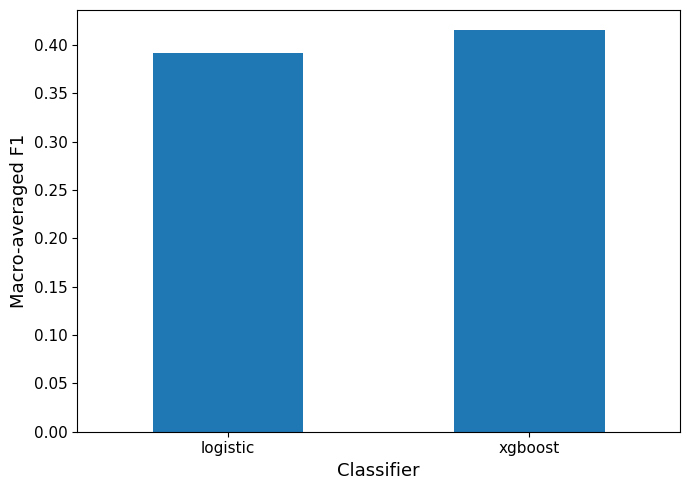

In [ ]:
model_comparison = (
    overall_metrics_df
    .set_index("model")
    .loc[
        MODEL_FAMILIES,
        "f1_macro",
    ]
)


ax = model_comparison.plot(
    kind="bar",
    figsize=(7, 5),
    legend=False,
)

ax.set_xlabel(
    "Classifier",
    fontsize=13,
)

ax.set_ylabel(
    "Macro-averaged F1",
    fontsize=13,
)

ax.tick_params(
    axis="both",
    labelsize=11,
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "model_comparison_macro_f1.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

## 14. Run the three model families

This is the computationally expensive section. The XGBoost search size can be reduced through `XGB_SEARCH_ITERATIONS` in the configuration cell.

In [ ]:
from sklearn.linear_model import SGDClassifier
MODEL_FAMILIES = [
    "logistic",
    "xgboost",
]


results = {}


for model_name in MODEL_FAMILIES:
    results[model_name] = (
        fit_fast_model_family(
            model_name=model_name,

            X_fit_transformed=(
                X_fit_transformed
            ),

            Y_fit_array=(
                Y_fit_array
            ),

            X_validation_transformed=(
                X_validation_transformed
            ),

            Y_validation_array=(
                Y_validation_array
            ),

            X_test_transformed=(
                X_test_transformed
            ),

            Y_test_array=(
                Y_test_array
            ),
        )
    )

[logistic] 1/14: Conceptualization


NameError: name 'role_metrics' is not defined

In [ ]:
results

{'dummy': {'models': {'Conceptualization': Pipeline(steps=[('preprocessor',
                    ColumnTransformer(transformers=[('numeric',
                                                     Pipeline(steps=[('imputer',
                                                                      SimpleImputer(strategy='median')),
                                                                     ('scaler',
                                                                      StandardScaler())]),
                                                     ['number_of_authors',
                                                      'normalized_author_position']),
                                                    ('categorical',
                                                     Pipeline(steps=[('imputer',
                                                                      SimpleImputer(strategy='most_frequent')),
                                                                     ('onehot',
 

## 15. Compare models and inspect per-role performance

Do not interpret average binary accuracy alone. A model predicting "absent" for every rare role can achieve high accuracy while having zero recall.

In [ ]:
overall_metrics_df = pd.concat(
    [results[name]["overall_metrics"] for name in MODEL_FAMILIES],
    ignore_index=True,
)

per_role_metrics_df = pd.concat(
    [results[name]["per_role_metrics"] for name in MODEL_FAMILIES],
    ignore_index=True,
)

display(
    overall_metrics_df[
        [
            "model",
            "subset_accuracy",
            "hamming_loss",
            "precision_micro",
            "recall_micro",
            "f1_micro",
            "precision_macro",
            "recall_macro",
            "f1_macro",
            "average_precision_micro",
            "average_precision_macro",
        ]
    ].sort_values("average_precision_macro", ascending=False)
)

display(
    per_role_metrics_df[
        [
            "model",
            "role",
            "support",
            "prevalence",
            "precision",
            "recall",
            "f1",
            "average_precision",
            "balanced_accuracy",
            "accuracy",
            "threshold",
        ]
    ].sort_values(["role", "model"])
)

,model,subset_accuracy,hamming_loss,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,average_precision_micro,average_precision_macro
1,xgboost,0.040095,0.340773,0.372735,0.645947,0.472703,0.345427,0.631048,0.395323,0.492365,0.378470
0,logistic,0.011825,0.412129,0.319535,0.657663,0.430100,0.297448,0.645863,0.362932,0.356781,0.336766


,model,role,support,prevalence,precision,recall,f1,average_precision,balanced_accuracy,accuracy,threshold
0,logistic,Conceptualization,279684,0.439852,0.521316,0.727167,0.607271,0.576582,0.601430,0.586305,0.5
14,xgboost,Conceptualization,279684,0.439852,0.676369,0.683539,0.679935,0.738710,0.713358,0.716945,0.5
1,logistic,Data Curation,61892,0.097336,0.138029,0.597509,0.224254,0.160110,0.597575,0.597628,0.5
15,xgboost,Data Curation,61892,0.097336,0.141345,0.609303,0.229460,0.164576,0.605084,0.601685,0.5
2,logistic,Formal Analysis,301194,0.473680,0.578047,0.611579,0.594341,0.651557,0.604899,0.604548,0.5
16,xgboost,Formal Analysis,301194,0.473680,0.654358,0.588634,0.619758,0.691716,0.654402,0.657864,0.5
3,logistic,Funding Acquisition,34682,0.054544,0.091360,0.660890,0.160529,0.105833,0.640846,0.622989,0.5
17,xgboost,Funding Acquisition,34682,0.054544,0.107698,0.648434,0.184716,0.131730,0.669249,0.687792,0.5
4,logistic,Investigation,306426,0.481909,0.645348,0.657434,0.651335,0.683485,0.660686,0.660804,0.5
18,xgboost,Investigation,306426,0.481909,0.636827,0.691903,0.663224,0.687210,0.662439,0.661373,0.5


## 16. Publication-ready figures

The figures deliberately have no internal title. Use the manuscript caption to describe them. Each bar series uses a single default color.

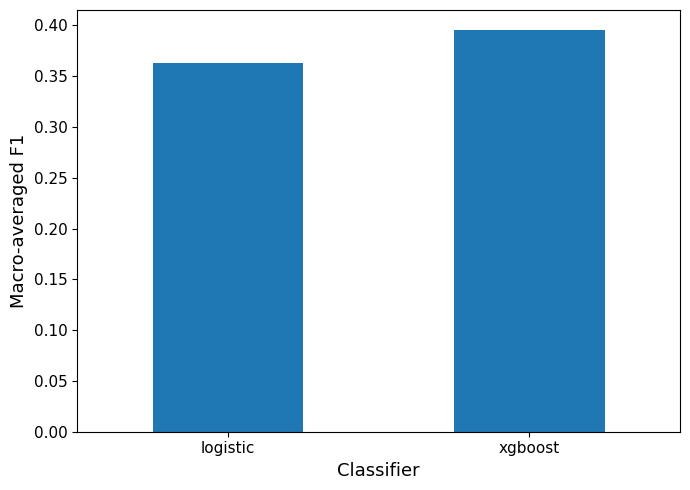

In [ ]:
comparison = (
    overall_metrics_df
    .set_index("model")
    .loc[MODEL_FAMILIES, ["f1_macro"]]
)

ax = comparison["f1_macro"].plot(kind="bar", figsize=(7, 5), legend=False)
ax.set_xlabel("Classifier", fontsize=13)
ax.set_ylabel("Macro-averaged F1", fontsize=13)
ax.tick_params(axis="both", labelsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison_macro_f1.png", dpi=600, bbox_inches="tight")
plt.show()

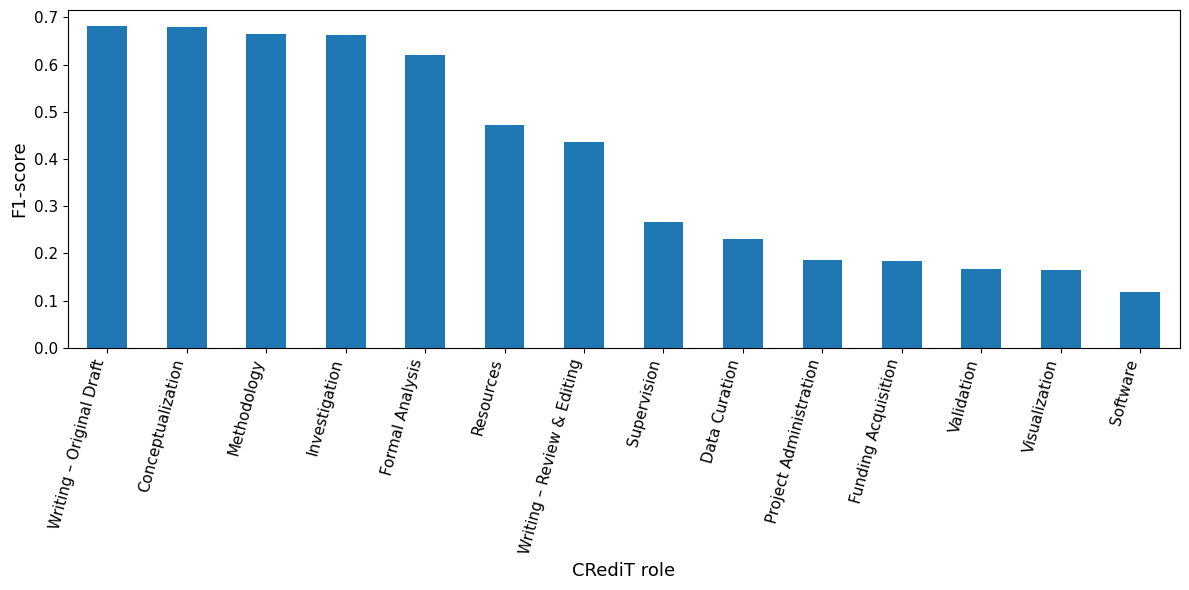

In [ ]:
best_model_name = (
    overall_metrics_df
    .sort_values("average_precision_macro", ascending=False)
    .iloc[0]["model"]
)

best_role_metrics = (
    per_role_metrics_df
    .loc[lambda frame: frame["model"].eq(best_model_name)]
    .sort_values("f1", ascending=False)
)

ax = best_role_metrics.plot(
    x="role",
    y="f1",
    kind="bar",
    figsize=(12, 6),
    legend=False,
)
ax.set_xlabel("CRediT role", fontsize=13)
ax.set_ylabel("F1-score", fontsize=13)
ax.tick_params(axis="both", labelsize=11)
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / f"{best_model_name}_per_role_f1.png",
    dpi=600,
    bbox_inches="tight",
)
plt.show()

## 17. Save reproducibility artifacts

The saved test-prediction file includes the original row ID, article grouping key, true labels, predicted labels, and role probabilities. The held-out test partition can therefore be audited independently.

In [ ]:
def roles_from_binary_row(binary_row):
    return [
        role for role, value in zip(CREDIT_ROLES, binary_row)
        if int(value) == 1
    ]

overall_metrics_df.to_csv(
    OUTPUT_DIR / "overall_model_metrics.csv",
    index=False,
)
per_role_metrics_df.to_csv(
    OUTPUT_DIR / "per_role_model_metrics.csv",
    index=False,
)
prevalence_comparison.to_csv(
    OUTPUT_DIR / "train_test_prevalence.csv",
)

split_manifest = pd.DataFrame({
    "_original_row_id": df["_original_row_id"],
    "_article_group": df["_article_group"],
    "partition": np.where(train_mask, "train", "test"),
})
split_manifest.to_csv(
    OUTPUT_DIR / "split_manifest.csv",
    index=False,
)

for model_name in MODEL_FAMILIES:
    model_result = results[model_name]

    prediction_output = meta_test[
        ["_original_row_id", "_article_group"]
    ].copy()
    prediction_output["true_roles"] = [
        roles_from_binary_row(row)
        for row in Y_test[CREDIT_ROLES].to_numpy()
    ]
    prediction_output["predicted_roles"] = [
        roles_from_binary_row(row)
        for row in model_result["predictions"]
    ]

    for role_index, role in enumerate(CREDIT_ROLES):
        safe_name = _label_key(role).replace(" ", "_")
        prediction_output[f"probability__{safe_name}"] = (
            model_result["probabilities"][:, role_index]
        )

    prediction_output.to_csv(
        OUTPUT_DIR / f"test_predictions_{model_name}.csv",
        index=False,
    )

    joblib.dump(
        model_result["models"],
        OUTPUT_DIR / f"fitted_models_{model_name}.joblib",
    )

    with open(
        OUTPUT_DIR / f"best_parameters_{model_name}.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            model_result["best_parameters"],
            file,
            ensure_ascii=False,
            indent=2,
            default=str,
        )

print("Saved files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(path.name)

## 18. Optional generalization tests

The primary article-level split prevents direct leakage. The following tests ask stricter and different questions:

- **Temporal holdout:** can a model trained on earlier years generalize to later years?
- **Unseen-journal holdout:** can it generalize to a publication venue not observed during training?
- **Unseen-domain holdout:** can it generalize across disciplinary contexts?

These should be described as robustness or external-validity analyses, not as substitutes for the article-level split.

In [ ]:
def temporal_holdout_masks(data, year_column, test_years):
    if year_column not in data.columns:
        raise ValueError(f"Missing year column: {year_column}")

    years = pd.to_numeric(data[year_column], errors="coerce")
    test_years = set(test_years)

    temporal_test = years.isin(test_years)
    temporal_train = years.notna() & ~temporal_test

    train_articles = set(data.loc[temporal_train, "_article_group"])
    test_articles = set(data.loc[temporal_test, "_article_group"])
    overlap = train_articles & test_articles
    if overlap:
        raise ValueError(
            "Some articles occur in both temporal partitions. "
            "Resolve inconsistent article-year metadata."
        )

    return temporal_train, temporal_test


def unseen_category_holdout_masks(data, column, held_out_value):
    if column not in data.columns:
        raise ValueError(f"Missing column: {column}")

    category_test = data[column].eq(held_out_value)
    category_train = ~category_test

    train_articles = set(data.loc[category_train, "_article_group"])
    test_articles = set(data.loc[category_test, "_article_group"])
    overlap = train_articles & test_articles
    if overlap:
        raise ValueError(
            f"Some articles have inconsistent values in {column}."
        )

    return category_train, category_test


# Examples:
# temporal_train_mask, temporal_test_mask = temporal_holdout_masks(
#     df, YEAR_COLUMN, test_years=[2024, 2025]
# )
#
# journal_train_mask, journal_test_mask = unseen_category_holdout_masks(
#     df, JOURNAL_COLUMN, held_out_value="PLOS ONE"
# )
#
# domain_train_mask, domain_test_mask = unseen_category_holdout_masks(
#     df, "domain", held_out_value="Social Sciences"
# )

## 19. Interpretation checklist

Before reporting the result:

1. State that the target is a self-declared CRediT assignment.
2. Do not describe last authors as "senior" unless seniority was measured.
3. Do not claim that predictive associations are causal.
4. Report the dummy baseline alongside trained models.
5. Report per-role support, precision, recall, F1, and average precision.
6. Report micro and macro averages; macro scores prevent common roles from dominating the summary.
7. Report the number of articles and author rows in each partition.
8. State that all authors from the same article were kept in one partition.
9. State that `number_of_tasks` was excluded as target-derived information.
10. Discuss that field, domain, author position, and team size may encode existing authorship conventions rather than true labor allocation.